In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/DataDNA Dataset Challenge - E-commerce Dataset - November 2025.xlsx")

In [3]:
df.head()

,event_id,event_type,event_date,customer_id,product_id,country,latitude,longitude,region,channel,...,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,DB4F1A096586,order,2024-12-09 00:11:27,CUST0001946,PROD0083,United States,39.8283,-98.5795,NaN,Website,...,36.70,NaN,0.0,0.00,110.10,1.00,110.10,False,NaT,NaN
1,3550A69EEA36,order,2025-08-11 21:31:03,CUST0003776,PROD0049,Australia,-25.2744,133.7751,APAC,Website,...,19.70,NaN,0.0,9.85,108.35,0.66,71.51,False,NaT,NaN
2,0C3CAE65E90C,order,2025-09-30 15:39:28,CUST0001105,PROD0075,Canada,56.1304,-106.3468,NaN,Website,...,20.12,NaN,0.0,1.01,21.13,1.00,21.13,False,NaT,NaN
3,7DDC83355865,invoice,2024-09-26 04:13:11,CUST0003164,PROD0017,United States,39.8283,-98.5795,NaN,Partner,...,19.00,NaN,0.0,0.00,190.00,1.00,190.00,False,NaT,NaN
4,DAE0B37D8815,order,2024-06-23 16:03:04,CUST0003410,PROD0099,United States,39.8283,-98.5795,NaN,Website,...,29.38,NaN,0.0,0.00,88.14,1.00,88.14,False,NaT,NaN


In [4]:
df.columns

Index(['event_id', 'event_type', 'event_date', 'customer_id', 'product_id',
       'country', 'latitude', 'longitude', 'region', 'channel',
       'payment_method', 'currency', 'quantity', 'unit_price_local',
       'discount_code', 'discount_local', 'tax_local', 'net_revenue_local',
       'fx_rate_to_usd', 'net_revenue_usd', 'is_refunded', 'refund_datetime',
       'refund_reason'],
      dtype='object')

In [5]:
df.shape

(48000, 23)

In [6]:
df.dtypes

,0
event_id,object
event_type,object
event_date,datetime64[ns]
customer_id,object
product_id,object
country,object
latitude,float64
longitude,float64
region,object
channel,object


In [7]:
df.isnull().sum()

,0
event_id,0
event_type,0
event_date,0
customer_id,0
product_id,0
country,0
latitude,0
longitude,0
region,19579
channel,0


In [8]:
# So the missing region is replacable by unkonwn
# the discount code is missing that may be beacuse they dont get any discount
# so we can replace it by no_discount
# Refund datetime not mention_because the refund datetime and redund reason
# are the products which is not refunded thats why they didn't mention the date and also the reason.

In [9]:
# So lets fill the missing

In [10]:
df['region'] = df['region'].fillna("Unkown")

In [11]:
df['discount_code'] = df['discount_code'].fillna("No_Discount")

In [12]:
df['refund_reason'] = df['refund_reason'].fillna("Not_Refunded")

In [13]:
# verify the missing value

In [14]:
df.isnull().sum()

,0
event_id,0
event_type,0
event_date,0
customer_id,0
product_id,0
country,0
latitude,0
longitude,0
region,0
channel,0


In [15]:
# refund_datetime is intentially showing 46995, that mean 46995 orders are not refunded yet.

In [16]:
# Lets find out the object columns

In [17]:
df.select_dtypes(include=["object"]).columns

Index(['event_id', 'event_type', 'customer_id', 'product_id', 'country',
       'region', 'channel', 'payment_method', 'currency', 'discount_code',
       'refund_reason'],
      dtype='object')

In [18]:
cat_col = ['event_id', 'event_type', 'customer_id', 'product_id', 'country',
       'region', 'channel', 'payment_method', 'currency', 'discount_code',
       'refund_reason']

In [19]:
for i in cat_col:
  print(i, " : - ", df[i].unique())
  print("............................")

event_id  : -  ['DB4F1A096586' '3550A69EEA36' '0C3CAE65E90C' ... '31681CA1A687'
 'E5332EABFA60' '64381905AD06']
............................
event_type  : -  ['order' 'invoice']
............................
customer_id  : -  ['CUST0001946' 'CUST0003776' 'CUST0001105' ... 'CUST0001996' 'CUST0001296'
 'CUST0003384']
............................
product_id  : -  ['PROD0083' 'PROD0049' 'PROD0075' 'PROD0017' 'PROD0099' 'PROD0026'
 'PROD0059' 'PROD0100' 'PROD0027' 'PROD0067' 'PROD0047' 'PROD0055'
 'PROD0078' 'PROD0074' 'PROD0076' 'PROD0053' 'PROD0003' 'PROD0033'
 'PROD0020' 'PROD0022' 'PROD0012' 'PROD0087' 'PROD0002' 'PROD0019'
 'PROD0025' 'PROD0029' 'PROD0041' 'PROD0077' 'PROD0023' 'PROD0035'
 'PROD0006' 'PROD0052' 'PROD0089' 'PROD0086' 'PROD0050' 'PROD0046'
 'PROD0072' 'PROD0008' 'PROD0007' 'PROD0080' 'PROD0039' 'PROD0084'
 'PROD0011' 'PROD0062' 'PROD0063' 'PROD0037' 'PROD0095' 'PROD0001'
 'PROD0048' 'PROD0090' 'PROD0042' 'PROD0082' 'PROD0060' 'PROD0073'
 'PROD0038' 'PROD0014' 'PROD0066' '

In [20]:
# Lets do the feature engineering
# Drop the event_id, Customer_id, and product_id

In [21]:
df.drop(columns=['event_id', 'customer_id', 'product_id'], inplace=True)

In [22]:
df.head()

,event_type,event_date,country,latitude,longitude,region,channel,payment_method,currency,quantity,unit_price_local,discount_code,discount_local,tax_local,net_revenue_local,fx_rate_to_usd,net_revenue_usd,is_refunded,refund_datetime,refund_reason
0,order,2024-12-09 00:11:27,United States,39.8283,-98.5795,Unkown,Website,Credit Card,USD,3,36.70,No_Discount,0.0,0.00,110.10,1.00,110.10,False,NaT,Not_Refunded
1,order,2025-08-11 21:31:03,Australia,-25.2744,133.7751,APAC,Website,Invoice,AUD,5,19.70,No_Discount,0.0,9.85,108.35,0.66,71.51,False,NaT,Not_Refunded
2,order,2025-09-30 15:39:28,Canada,56.1304,-106.3468,Unkown,Website,Credit Card,USD,1,20.12,No_Discount,0.0,1.01,21.13,1.00,21.13,False,NaT,Not_Refunded
3,invoice,2024-09-26 04:13:11,United States,39.8283,-98.5795,Unkown,Partner,Credit Card,USD,10,19.00,No_Discount,0.0,0.00,190.00,1.00,190.00,False,NaT,Not_Refunded
4,order,2024-06-23 16:03:04,United States,39.8283,-98.5795,Unkown,Website,Credit Card,USD,3,29.38,No_Discount,0.0,0.00,88.14,1.00,88.14,False,NaT,Not_Refunded


In [23]:
# Lets check the duplicate records

df.duplicated().sum()

np.int64(0)

In [24]:
# Lets start for EDA -

In [25]:
df.columns

Index(['event_type', 'event_date', 'country', 'latitude', 'longitude',
       'region', 'channel', 'payment_method', 'currency', 'quantity',
       'unit_price_local', 'discount_code', 'discount_local', 'tax_local',
       'net_revenue_local', 'fx_rate_to_usd', 'net_revenue_usd', 'is_refunded',
       'refund_datetime', 'refund_reason'],
      dtype='object')

In [26]:
# lets check for the event types

In [27]:
df['event_type'].unique()

array(['order', 'invoice'], dtype=object)

In [28]:
df['event_type'].value_counts()

,count
event_type,
order,33601
invoice,14399


In [29]:
df.groupby('event_type')['net_revenue_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
event_type,,,,,,,,
invoice,14399.0,651.337073,1174.999209,4.0,53.90,196.28,660.01,14969.85
order,33601.0,668.244367,1194.135810,4.0,55.02,200.00,687.36,14970.13


In [30]:
df['is_refunded'].unique()

array([False,  True])

In [31]:
df.groupby('event_type')['is_refunded'].value_counts().unstack()

is_refunded,False,True
event_type,,
invoice,14083,316
order,32912,689


<Axes: xlabel='event_type', ylabel='count'>

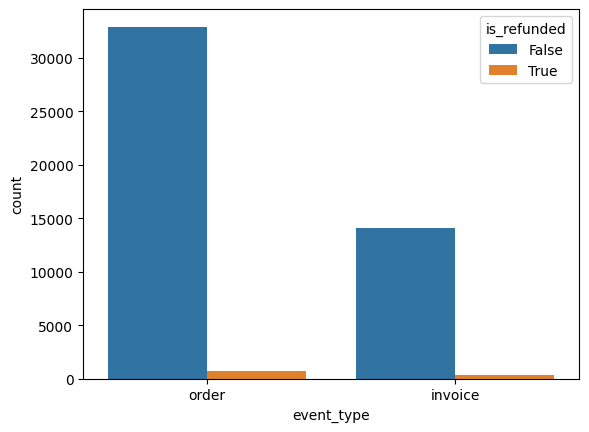

In [32]:
sns.countplot(data=df, x="event_type", hue= "is_refunded")

In [33]:
df.groupby('event_type')['payment_method'].value_counts().unstack()

payment_method,Credit Card,Invoice,PayPal,Wire
event_type,,,,
invoice,7958,3575,2138,728
order,18382,8480,5077,1662


In [34]:
df.groupby(['event_type','payment_method'])["is_refunded"].value_counts().unstack()

is_refunded                False  True 
event_type payment_method              
invoice    Credit Card      7783    175
           Invoice          3504     71
           PayPal           2087     51
           Wire              709     19
order      Credit Card     18001    381
           Invoice          8315    165
           PayPal           4976    101
           Wire             1620     42

In [35]:
stack = df.groupby(['event_type','payment_method'])["is_refunded"].value_counts().unstack()

<Axes: xlabel='event_type,payment_method'>

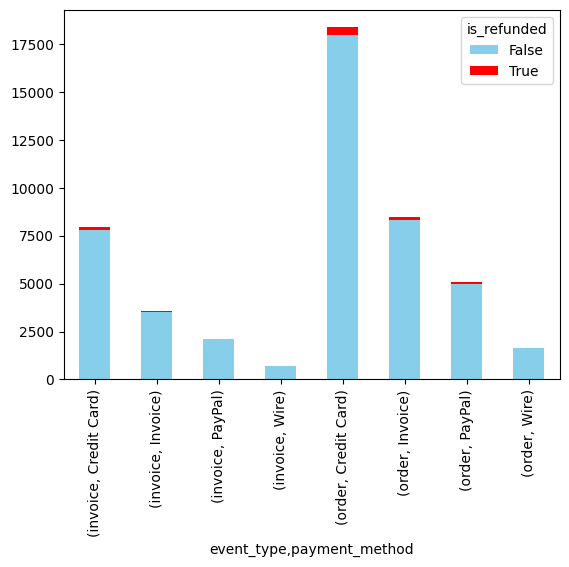

In [36]:
stack.plot(kind='bar', stacked=True, color=['skyblue', 'red'])

In [37]:
# lets check for channel

In [38]:
df['channel'].unique()

array(['Website', 'Partner', 'Direct Sales', 'Marketplace', 'Reseller'],
      dtype=object)

In [39]:
df['channel'].value_counts()

,count
channel,
Website,21549
Direct Sales,9792
Reseller,6914
Partner,4884
Marketplace,4861


In [40]:
df.groupby('channel')['net_revenue_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
channel,,,,,,,,
Direct Sales,9792.0,649.499948,1159.388983,4.0,54.00,192.00,669.6100,14969.85
Marketplace,4861.0,687.954980,1241.018629,4.0,60.00,206.99,709.2200,13098.75
Partner,4884.0,665.892877,1188.215145,4.0,56.76,209.48,686.7800,11976.11
Reseller,6914.0,644.470784,1151.176021,4.0,54.00,200.00,671.6275,14970.13
Website,21549.0,669.178942,1201.063832,4.0,54.02,199.00,680.0000,14969.85


In [41]:
df.groupby('channel')['is_refunded'].value_counts().unstack()

is_refunded,False,True
channel,,
Direct Sales,9590,202
Marketplace,4746,115
Partner,4785,99
Reseller,6774,140
Website,21100,449


<Axes: xlabel='channel', ylabel='count'>

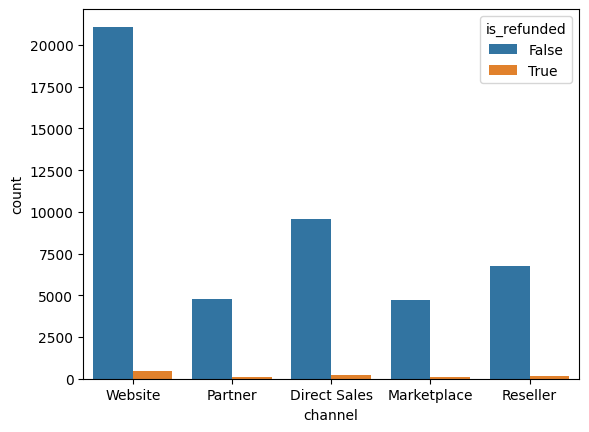

In [42]:
sns.countplot(data=df, x="channel", hue="is_refunded")

In [43]:
df['country'].unique()

array(['United States', 'Australia', 'Canada', 'Germany', 'Brazil',
       'United Kingdom', 'France', 'Philippines', 'Spain', 'Netherlands'],
      dtype=object)

In [44]:
df['country'].value_counts()

,count
country,
United States,14735
United Kingdom,7262
Canada,4844
Australia,4836
Germany,3587
France,3337
Netherlands,2519
Philippines,2470
Spain,2335


In [45]:
df.groupby('country')['net_revenue_usd'].describe()

,count,mean,std,min,25%,50%,75%,max
country,,,,,,,,
Australia,4836.0,660.224595,1153.819390,4.50,55.000,199.000,675.46,9979.99
Brazil,2075.0,719.426145,1287.094720,4.75,57.155,230.000,747.50,11477.00
Canada,4844.0,659.417620,1191.711372,4.25,51.450,191.195,682.50,13098.75
France,3337.0,731.454975,1284.679763,5.00,59.280,220.180,779.99,13722.36
Germany,3587.0,748.568366,1316.178900,5.25,60.000,227.940,779.99,11975.88
Netherlands,2519.0,723.885208,1317.864202,5.00,60.000,220.000,776.06,14969.85
Philippines,2470.0,681.390668,1202.940606,4.75,57.500,223.200,690.00,11477.00
Spain,2335.0,731.515109,1336.739511,5.25,60.040,227.050,749.97,12474.88
United Kingdom,7262.0,693.336417,1233.840448,5.00,57.580,212.300,716.04,14970.13


In [46]:
df.groupby('country')['is_refunded'].value_counts().unstack()

is_refunded,False,True
country,,
Australia,4724,112
Brazil,2024,51
Canada,4729,115
France,3268,69
Germany,3508,79
Netherlands,2469,50
Philippines,2428,42
Spain,2293,42
United Kingdom,7105,157


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'United States'),
  Text(1, 0, 'Australia'),
  Text(2, 0, 'Canada'),
  Text(3, 0, 'Germany'),
  Text(4, 0, 'Brazil'),
  Text(5, 0, 'United Kingdom'),
  Text(6, 0, 'France'),
  Text(7, 0, 'Philippines'),
  Text(8, 0, 'Spain'),
  Text(9, 0, 'Netherlands')])

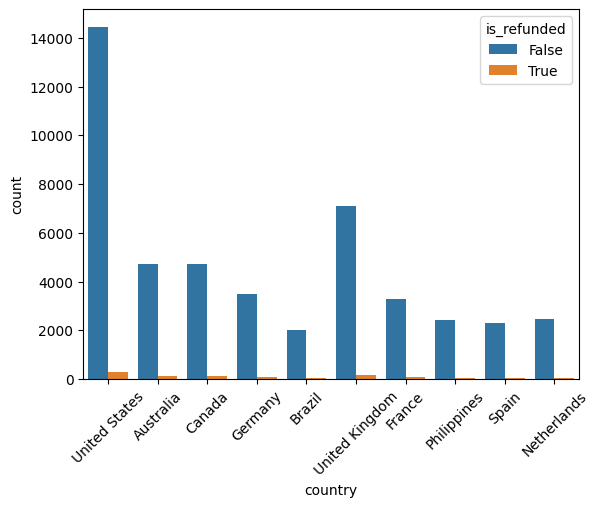

In [47]:
sns.countplot(data=df, x="country", hue= "is_refunded")
plt.xticks(rotation=45)

In [48]:
# what is total no. of record, and unique

In [49]:
df.shape

(48000, 20)

In [50]:
len(df)

48000

In [51]:
# Total record is 48000

In [52]:
df['event_type'].unique()

array(['order', 'invoice'], dtype=object)

In [53]:
# 3 - Time range of dataset

In [54]:
min_date = df['event_date'].min()

In [55]:
max_date = df['event_date'].max()

In [56]:
print("The Range is from", min_date, "to", max_date)

The Range is from 2024-04-22 00:09:01 to 2025-10-21 23:56:20


In [57]:
print(f"The Range is from {min_date} to {max_date}")

The Range is from 2024-04-22 00:09:01 to 2025-10-21 23:56:20


In [58]:
# 4 - Duplicate or missing data

In [59]:
df.duplicated().sum()

np.int64(0)

In [60]:
df.isnull().sum()

,0
event_type,0
event_date,0
country,0
latitude,0
longitude,0
region,0
channel,0
payment_method,0
currency,0
quantity,0


In [61]:
for i in ["event_date", "country", "net_revenue_usd"]:
  print(f"duplicated values in {i} is", df[i].duplicated().sum())
  print(f"missing values in {i} is", df[i].isnull().sum())
  print(".................................................")

duplicated values in event_date is 24
missing values in event_date is 0
.................................................
duplicated values in country is 47990
missing values in country is 0
.................................................
duplicated values in net_revenue_usd is 42717
missing values in net_revenue_usd is 0
.................................................


In [62]:
# 5 - Country by most total revenue in USD

In [63]:
rev = df.groupby("country")["net_revenue_usd"].sum().sort_values(ascending=False)

In [64]:
top5 = rev.head(5)

In [65]:
top5

,net_revenue_usd
country,
United States,8576828.53
United Kingdom,5035009.06
Canada,3194218.95
Australia,3192846.14
Germany,2685114.73


In [66]:
top5 = top5.reset_index()

/tmp/ipython-input-2903627896.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top5, x="country", y="net_revenue_usd", palette="Set2")


<Axes: xlabel='country', ylabel='net_revenue_usd'>

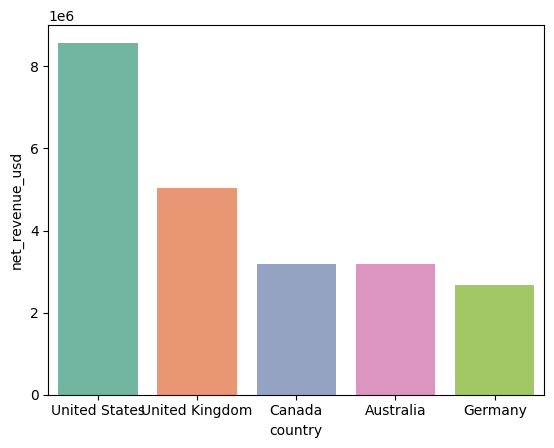

In [67]:
sns.barplot(data=top5, x="country", y="net_revenue_usd", palette="Set2")

In [68]:
# 6 - average order value of net revenue

In [69]:
df.groupby("region")["net_revenue_usd"].mean().sort_values(ascending=False)

,net_revenue_usd
region,
LATAM,719.426145
EU,719.146201
APAC,667.380385
Unkown,601.207798


In [70]:
avg = df.groupby("region")["net_revenue_usd"].mean().sort_values(ascending=False).reset_index()

In [71]:
avg

,region,net_revenue_usd
0,LATAM,719.426145
1,EU,719.146201
2,APAC,667.380385
3,Unkown,601.207798


/tmp/ipython-input-4247384070.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg, x="region", y="net_revenue_usd", palette="viridis")


<Axes: xlabel='region', ylabel='net_revenue_usd'>

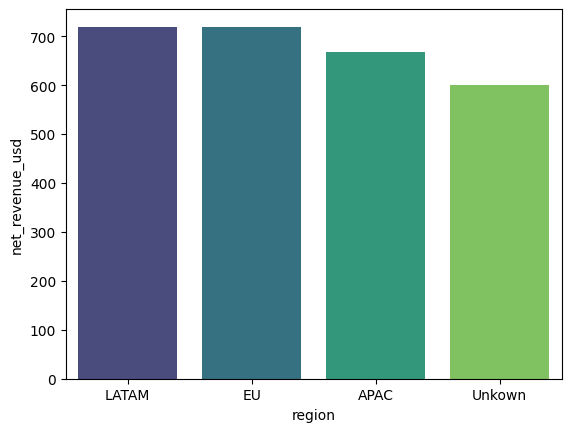

In [72]:
sns.barplot(data=avg, x="region", y="net_revenue_usd", palette="viridis")

In [73]:
df.groupby("country")["net_revenue_usd"].mean().sort_values(ascending=False).reset_index()

,country,net_revenue_usd
0,Germany,748.568366
1,Spain,731.515109
2,France,731.454975
3,Netherlands,723.885208
4,Brazil,719.426145
5,United Kingdom,693.336417
6,Philippines,681.390668
7,Australia,660.224595
8,Canada,659.417620
9,United States,582.071838


In [74]:
avg1 = df.groupby("country")["net_revenue_usd"].mean().sort_values(ascending=False).reset_index()

In [75]:
avg1 = avg1.head(5)

In [76]:
avg1

,country,net_revenue_usd
0,Germany,748.568366
1,Spain,731.515109
2,France,731.454975
3,Netherlands,723.885208
4,Brazil,719.426145


/tmp/ipython-input-678126337.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=avg1, x= "country", y= "net_revenue_usd", palette="viridis")


<Axes: xlabel='country', ylabel='net_revenue_usd'>

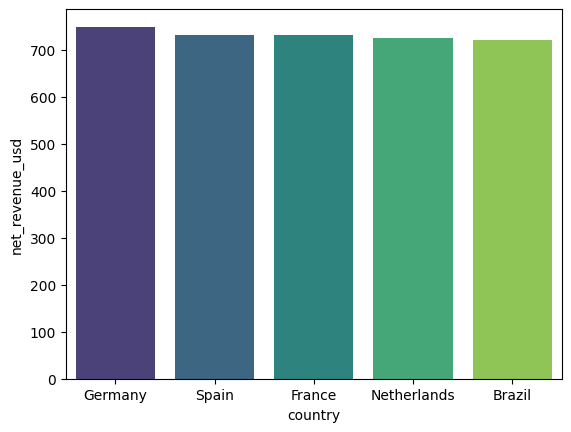

In [77]:
sns.barplot(data=avg1, x= "country", y= "net_revenue_usd", palette="viridis")

In [78]:
# 7 - No. of orders varry accross region and counrty

In [79]:
df['region'].value_counts().sort_values()

,count
region,
LATAM,2075
APAC,7306
EU,19040
Unkown,19579


In [80]:
reg = df['region'].value_counts().sort_values().reset_index()

In [81]:
reg

,region,count
0,LATAM,2075
1,APAC,7306
2,EU,19040
3,Unkown,19579


/tmp/ipython-input-3382882277.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg, x="region", y="count", palette="viridis")


<Axes: xlabel='region', ylabel='count'>

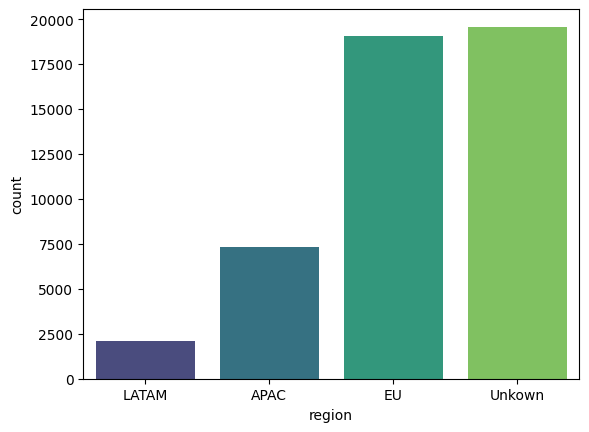

In [82]:
sns.barplot(data=reg, x="region", y="count", palette="viridis")

In [83]:
df['country'].value_counts().sort_values()

,count
country,
Brazil,2075
Spain,2335
Philippines,2470
Netherlands,2519
France,3337
Germany,3587
Australia,4836
Canada,4844
United Kingdom,7262


In [84]:
reg1 = df['country'].value_counts().sort_values().reset_index()

In [85]:
reg1

,country,count
0,Brazil,2075
1,Spain,2335
2,Philippines,2470
3,Netherlands,2519
4,France,3337
5,Germany,3587
6,Australia,4836
7,Canada,4844
8,United Kingdom,7262
9,United States,14735


/tmp/ipython-input-1901089056.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=reg1, x="country", y="count", palette="viridis")


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Brazil'),
  Text(1, 0, 'Spain'),
  Text(2, 0, 'Philippines'),
  Text(3, 0, 'Netherlands'),
  Text(4, 0, 'France'),
  Text(5, 0, 'Germany'),
  Text(6, 0, 'Australia'),
  Text(7, 0, 'Canada'),
  Text(8, 0, 'United Kingdom'),
  Text(9, 0, 'United States')])

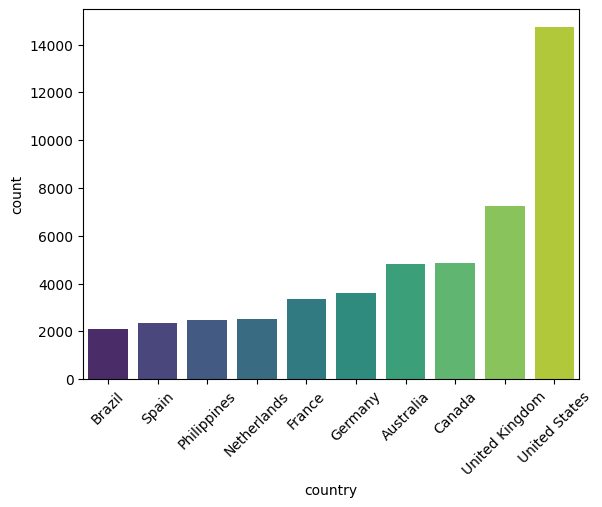

In [86]:
sns.barplot(data=reg1, x="country", y="count", palette="viridis")
plt.xticks(rotation=45)

In [87]:
# 8 - Which country shows the highest refund rate

In [94]:
df.groupby("country")["is_refunded"].mean().sort_values(ascending=False)*100

,is_refunded
country,
Brazil,2.457831
Canada,2.374071
Australia,2.315964
Germany,2.202398
United Kingdom,2.161939
France,2.067726
Netherlands,1.984915
United States,1.954530
Spain,1.798715


In [106]:
high = df.groupby("country")["is_refunded"].mean().sort_values(ascending=False)*100

In [107]:
high= high.head(5)

In [108]:
high

,is_refunded
country,
Brazil,2.457831
Canada,2.374071
Australia,2.315964
Germany,2.202398
United Kingdom,2.161939


In [109]:
high = high.reset_index()

In [110]:
high

,country,is_refunded
0,Brazil,2.457831
1,Canada,2.374071
2,Australia,2.315964
3,Germany,2.202398
4,United Kingdom,2.161939


/tmp/ipython-input-1560741164.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=high, x="is_refunded", y="country", palette="mako")


<Axes: xlabel='is_refunded', ylabel='country'>

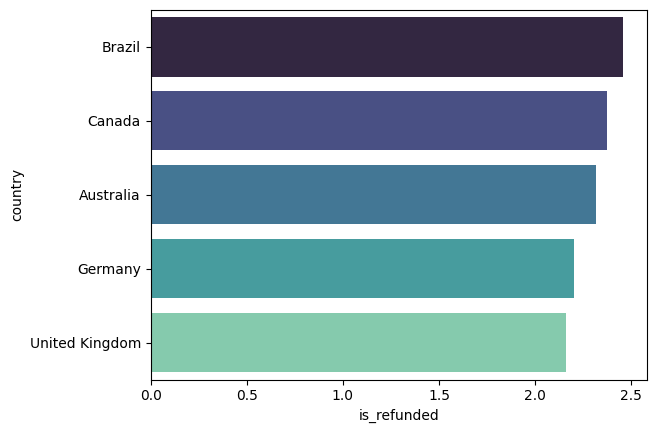

In [111]:
sns.barplot(data=high, x="is_refunded", y="country", palette="mako")

In [112]:
# 9 - Channels - transctions and revenue

In [114]:
df['channel'].value_counts()

,count
channel,
Website,21549
Direct Sales,9792
Reseller,6914
Partner,4884
Marketplace,4861


In [118]:
df.groupby("channel")["net_revenue_usd"].sum().sort_values()

,net_revenue_usd
channel,
Partner,3252220.81
Marketplace,3344149.16
Reseller,4455871.00
Direct Sales,6359903.49
Website,14420137.02


In [119]:
trans = df.groupby("channel")["net_revenue_usd"].sum().sort_values()

In [120]:
trans = trans.reset_index()

In [121]:
trans

,channel,net_revenue_usd
0,Partner,3252220.81
1,Marketplace,3344149.16
2,Reseller,4455871.00
3,Direct Sales,6359903.49
4,Website,14420137.02


/tmp/ipython-input-2588322012.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=trans, x="channel", y="net_revenue_usd", palette="viridis")


<Axes: xlabel='channel', ylabel='net_revenue_usd'>

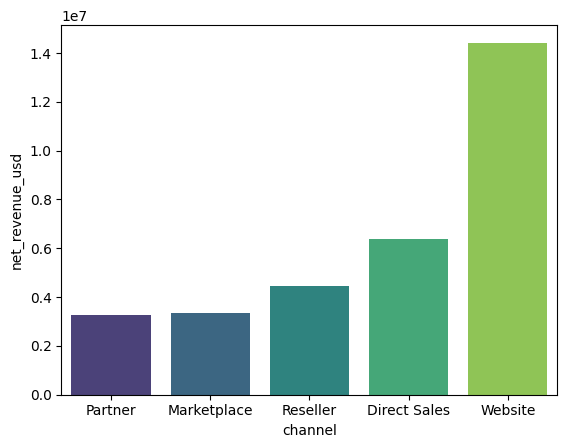

In [126]:
sns.barplot(data=trans, x="channel", y="net_revenue_usd", palette="viridis")

In [127]:
# 10 - payment method frequency accross region

In [128]:
df.columns

Index(['event_type', 'event_date', 'country', 'latitude', 'longitude',
       'region', 'channel', 'payment_method', 'currency', 'quantity',
       'unit_price_local', 'discount_code', 'discount_local', 'tax_local',
       'net_revenue_local', 'fx_rate_to_usd', 'net_revenue_usd', 'is_refunded',
       'refund_datetime', 'refund_reason'],
      dtype='object')

In [129]:
df['payment_method'].unique()

array(['Credit Card', 'Invoice', 'Wire', 'PayPal'], dtype=object)

In [130]:
df['payment_method'].value_counts()

,count
payment_method,
Credit Card,26340
Invoice,12055
PayPal,7215
Wire,2390


In [131]:
df.groupby("region")["payment_method"].value_counts().unstack()

payment_method,Credit Card,Invoice,PayPal,Wire
region,,,,
APAC,3973,1843,1131,359
EU,10476,4745,2882,937
LATAM,1155,508,313,99
Unkown,10736,4959,2889,995


In [132]:
# 11 - relationship between payment method and refund probability

In [135]:
rel = df.groupby("payment_method")["is_refunded"].mean()*100

In [136]:
rel = rel.reset_index()

In [137]:
rel

,payment_method,is_refunded
0,Credit Card,2.110858
1,Invoice,1.957694
2,PayPal,2.106722
3,Wire,2.552301


/tmp/ipython-input-1009606468.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rel, x="payment_method", y="is_refunded", palette="Set1")


<Axes: xlabel='payment_method', ylabel='is_refunded'>

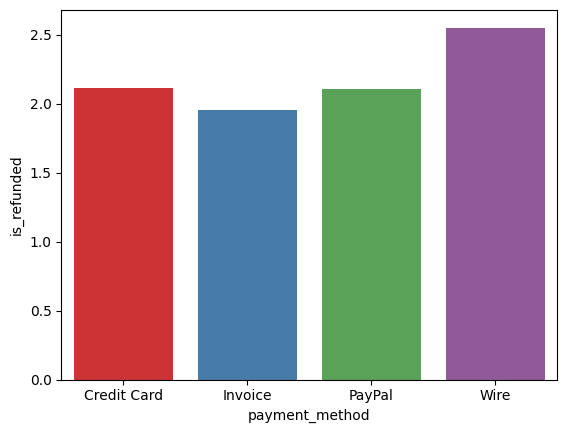

In [141]:
sns.barplot(data=rel, x="payment_method", y="is_refunded", palette="Set1")

In [142]:
# 12 - average order value by sale channel or payment method

In [155]:
channel = df.groupby("channel")["net_revenue_usd"].mean().sort_values(ascending=False)

In [156]:
channel = channel.reset_index()

In [157]:
channel

,channel,net_revenue_usd
0,Marketplace,687.954980
1,Website,669.178942
2,Partner,665.892877
3,Direct Sales,649.499948
4,Reseller,644.470784


In [158]:
pay_method = df.groupby("payment_method")["net_revenue_usd"].mean().sort_values(ascending=False)

In [159]:
pay_method = pay_method.reset_index()

In [160]:
pay_method

,payment_method,net_revenue_usd
0,Credit Card,676.549828
1,Wire,655.979816
2,Invoice,647.913994
3,PayPal,642.212618


/tmp/ipython-input-1453525593.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel, x="channel", y="net_revenue_usd", palette="viridis")


<Axes: xlabel='channel', ylabel='net_revenue_usd'>

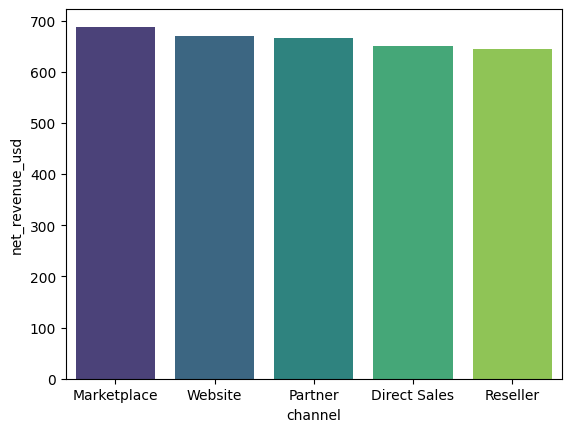

In [161]:
sns.barplot(data=channel, x="channel", y="net_revenue_usd", palette="viridis")

/tmp/ipython-input-158394375.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(pay_method, x="payment_method", y="net_revenue_usd", palette="viridis")


<Axes: xlabel='payment_method', ylabel='net_revenue_usd'>

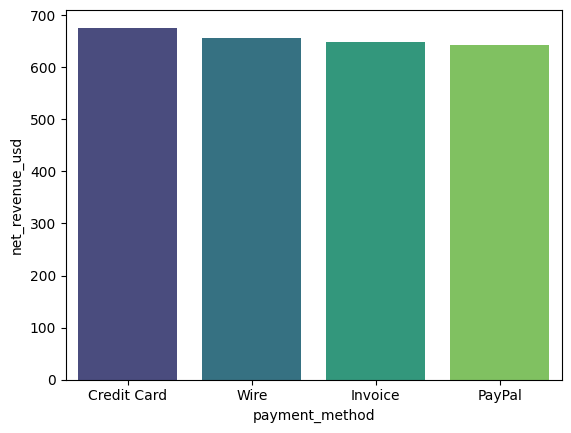

In [163]:
sns.barplot(pay_method, x="payment_method", y="net_revenue_usd", palette="viridis")

In [165]:
Q1 = df['net_revenue_usd'].quantile(0.25)

In [166]:
Q1

np.float64(54.34)

In [167]:
Q3 = df['net_revenue_usd'].quantile(0.75)

In [168]:
Q3

np.float64(675.46)

In [169]:
IQR = Q3 - Q1

In [170]:
IQR

np.float64(621.12)

In [171]:
Lower_bound = Q1 - 1.5 * IQR

In [172]:
Lower_bound

np.float64(-877.34)

In [173]:
Upper_bound = Q3 + 1.5 * 100

In [174]:
Upper_bound

np.float64(825.46)

<Axes: ylabel='net_revenue_usd'>

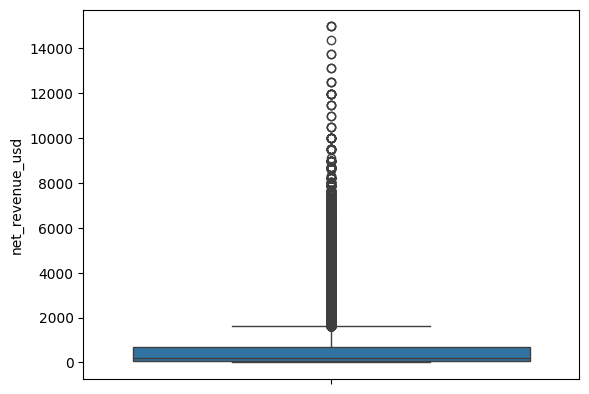

In [175]:
sns.boxplot(df['net_revenue_usd'])

In [176]:
df['event_date'].head()

,event_date
0,2024-12-09 00:11:27
1,2025-08-11 21:31:03
2,2025-09-30 15:39:28
3,2024-09-26 04:13:11
4,2024-06-23 16:03:04


In [178]:
df['event_date'].dtype

dtype('<M8[ns]')

In [179]:
df["Month"] = df['event_date'].dt.to_period("M")

In [180]:
df["Month"].head(5)

,Month
0,2024-12
1,2025-08
2,2025-09
3,2024-09
4,2024-06
